# Изучаю количество уникальных выходных переменных

In [1]:
import os
import json
from collections import Counter

def analyze_diagnoses_with_top10(folder_path):
    """
    Анализ диагнозов с выводом полного списка и отдельно топ-10
    """
    diagnosis_counter = Counter()
    display_names = {}  # Словарь для хранения display_name по diagnosis_text
    total_files = 0
    processed_files = 0
    
    if not os.path.exists(folder_path):
        print(f"Ошибка: Папка '{folder_path}' не существует!")
        return
    
    # Анализируем файлы
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            total_files += 1
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    display_name = data['diagnosis'].get('display_name')
                    
                    # Обработка случая, когда display_name может быть None
                    if display_name is None:
                        display_name = 'НЕТ НАЗВАНИЯ'
                    
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        # Сохраняем display_name для данного diagnosis_text
                        if diagnosis_text not in display_names:
                            display_names[diagnosis_text] = display_name
                        processed_files += 1
                        
            except Exception as e:
                print(f"Ошибка в файле {filename}: {e}")
    
    # ВЫВОД ТОП-10 ОТДЕЛЬНО
    print("="*80)
    print("ТОП-10 САМЫХ ЧАСТЫХ ДИАГНОЗОВ")
    print("="*80)
    
    top_10 = diagnosis_counter.most_common(10)
    for i, (diagnosis_text, count) in enumerate(top_10, 1):
        display_name = display_names.get(diagnosis_text, 'НЕТ НАЗВАНИЯ')
        # Дополнительная проверка на None
        if display_name is None:
            display_name = 'НЕТ НАЗВАНИЯ'
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis_text:<8} - {display_name:<30} - {count:3d} случаев ({percentage:6.1f}%)")
    
    # Общая статистика по топ-10
    top_10_total_cases = sum(count for _, count in top_10)
    top_10_percentage = (top_10_total_cases / processed_files) * 100
    print(f"\nТоп-10 диагнозов покрывают: {top_10_total_cases}/{processed_files} случаев ({top_10_percentage:.1f}%)")
    
    # ВЫВОД ПОЛНОГО СПИСКА ВСЕХ ДИАГНОЗОВ
    print("\n" + "="*80)
    print(f"ПОЛНЫЙ СПИСОК ВСЕХ ДИАГНОЗОВ ({len(diagnosis_counter)} видов)")
    print("="*80)
    
    for i, (diagnosis_text, count) in enumerate(diagnosis_counter.most_common(), 1):
        display_name = display_names.get(diagnosis_text, 'НЕТ НАЗВАНИЯ')
        # Дополнительная проверка на None
        if display_name is None:
            display_name = 'НЕТ НАЗВАНИЯ'
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis_text:<8} - {display_name:<30} - {count:3d} случаев ({percentage:6.1f}%)")
    
    # ОБЩАЯ СТАТИСТИКА
    print("\n" + "="*60)
    print("ОБЩАЯ СТАТИСТИКА")
    print("="*60)
    print(f"Всего файлов: {total_files}")
    print(f"Файлов с диагнозами: {processed_files}")
    print(f"Уникальных диагнозов: {len(diagnosis_counter)}")
    
    # Дополнительная информация
    single_occurrence = sum(1 for count in diagnosis_counter.values() if count == 1)
    print(f"Диагнозы, встречающиеся 1 раз: {single_occurrence}")
    print(f"Диагнозы, встречающиеся >1 раза: {len(diagnosis_counter) - single_occurrence}")

# Альтернативный вариант с более красивым форматированием
def analyze_diagnoses_pretty(folder_path):
    """
    Красивое форматирование вывода
    """
    diagnosis_counter = Counter()
    display_names = {}
    processed_files = 0
    
    # Собираем данные
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    display_name = data['diagnosis'].get('display_name')
                    
                    # Обработка случая, когда display_name может быть None
                    if display_name is None:
                        display_name = 'НЕТ НАЗВАНИЯ'
                    
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        if diagnosis_text not in display_names:
                            display_names[diagnosis_text] = display_name
                        processed_files += 1
            except Exception:
                continue
    
    # ТОП-10 в красивом формате
    print("🎯 ТОП-10 САМЫХ ЧАСТЫХ ДИАГНОЗОВ")
    print("═" * 70)
    
    top_10 = diagnosis_counter.most_common(10)
    # Безопасное вычисление максимальной длины
    display_name_lengths = [len(display_names.get(diagnosis, 'НЕТ НАЗВАНИЯ')) for diagnosis, _ in top_10]
    max_display_name_len = max(display_name_lengths) if display_name_lengths else 20
    
    for i, (diagnosis_text, count) in enumerate(top_10, 1):
        display_name = display_names.get(diagnosis_text, 'НЕТ НАЗВАНИЯ')
        if display_name is None:
            display_name = 'НЕТ НАЗВАНИЯ'
        percentage = (count / processed_files) * 100
        bar = "█" * int(percentage / 2)  # Визуализация в процентах
        print(f"{i:2d}. {diagnosis_text:<8} - {display_name:<{max_display_name_len}} - {count:3d} 📊 {percentage:5.1f}% {bar}")
    
    # Полный список
    print(f"\n📋 ПОЛНЫЙ СПИСОК ДИАГНОЗОВ ({len(diagnosis_counter)} видов)")
    print("═" * 70)
    
    all_diagnoses = diagnosis_counter.most_common()
    for i, (diagnosis_text, count) in enumerate(all_diagnoses, 1):
        display_name = display_names.get(diagnosis_text, 'НЕТ НАЗВАНИЯ')
        if display_name is None:
            display_name = 'НЕТ НАЗВАНИЯ'
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis_text:<8} - {display_name:<{max_display_name_len}} - {count:3d} случаев ({percentage:5.1f}%)")

# Компактный вариант
def analyze_diagnoses_compact(folder_path):
    """
    Компактный вывод
    """
    diagnosis_counter = Counter()
    display_names = {}
    processed_files = 0
    
    # Собираем данные
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    display_name = data['diagnosis'].get('display_name')
                    
                    # Обработка случая, когда display_name может быть None
                    if display_name is None:
                        display_name = 'НЕТ НАЗВАНИЯ'
                    
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        if diagnosis_text not in display_names:
                            display_names[diagnosis_text] = display_name
                        processed_files += 1
            except Exception:
                continue
    
    # ТОП-10
    print("ТОП-10 ДИАГНОЗОВ:")
    print("-" * 60)
    top_10 = diagnosis_counter.most_common(10)
    for i, (diagnosis_text, count) in enumerate(top_10, 1):
        display_name = display_names.get(diagnosis_text, 'НЕТ НАЗВАНИЯ')
        if display_name is None:
            display_name = 'НЕТ НАЗВАНИЯ'
        percentage = (count / processed_files) * 100
        print(f"{i}. {diagnosis_text} - {display_name} - {count} ({percentage:.1f}%)")
    
    # Все диагнозы
    print(f"\nВСЕ ДИАГНОЗЫ ({len(diagnosis_counter)}):")
    print("-" * 60)
    all_diagnoses = diagnosis_counter.most_common()
    for i, (diagnosis_text, count) in enumerate(all_diagnoses, 1):
        display_name = display_names.get(diagnosis_text, 'НЕТ НАЗВАНИЯ')
        if display_name is None:
            display_name = 'НЕТ НАЗВАНИЯ'
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis_text} - {display_name} - {count} ({percentage:.1f}%)")

# Запуск анализа
folder_path = "preprocessed_medical_results"

print("Анализ медицинских диагнозов")
print("Папка:", folder_path)
print()

# Выберите один из вариантов:
analyze_diagnoses_with_top10(folder_path)  # Основной вариант
# analyze_diagnoses_pretty(folder_path)     # Красивый вариант с emoji
# analyze_diagnoses_compact(folder_path)    # Компактный вариант

Анализ медицинских диагнозов
Папка: preprocessed_medical_results

ТОП-10 САМЫХ ЧАСТЫХ ДИАГНОЗОВ
 1. J44.8    - НЕТ НАЗВАНИЯ                   - 204 случаев (  10.1%)
 2. D14.3    - Доброкачественное новообразование бронха и легкого - 185 случаев (   9.2%)
 3. U07.1    - COVID-19, вирус идентифицирован - 167 случаев (   8.3%)
 4. A15.0    - Туберкулез легких, подтвержденный бактериоскопически с наличием или отсутствием роста культуры - 163 случаев (   8.1%)
 5. C34.1    - Злокачественное новообразование верхней доли, бронхов или легкого - 155 случаев (   7.7%)
 6. C34.3    - Злокачественное новообразование нижней доли, бронхов или легкого - 119 случаев (   5.9%)
 7. J44.1    - Хроническая обструктивная легочная болезнь с обострением неуточненная - 118 случаев (   5.9%)
 8. J15.8    - Другие бактериальные пневмонии -  91 случаев (   4.5%)
 9. A16.0    - Туберкулез легких при отрицательных результатах бактериологических и гистологических исследований -  84 случаев (   4.2%)
10. J45.9    -

# Объеденение классов

Из попыток обучения модели было установлено, что есть смысл рассмотреть возможность объеденения нескольких классов в один.

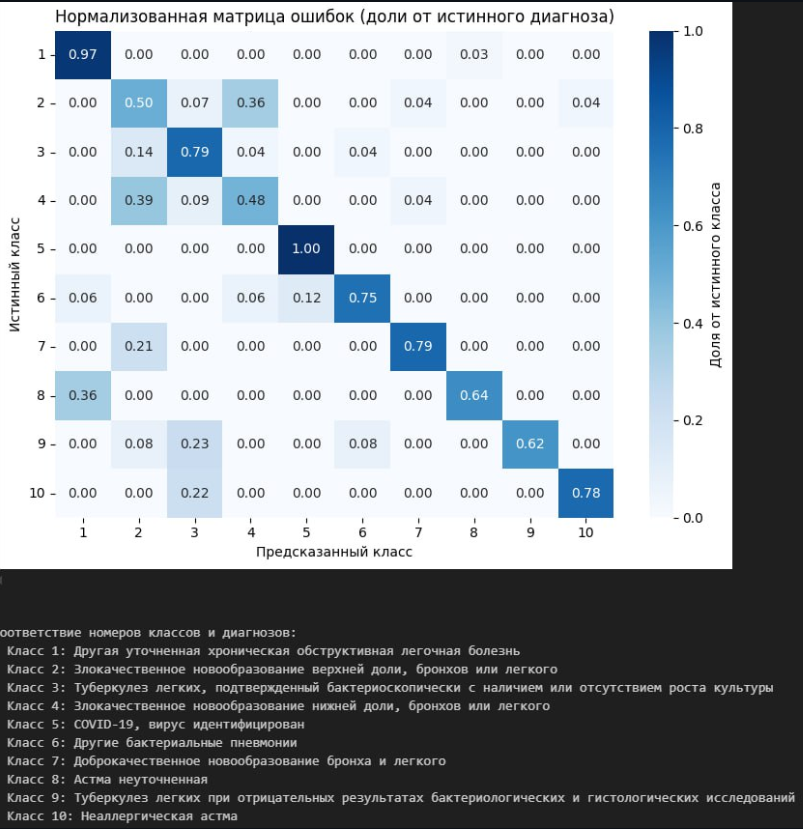

Было решено объеденить 2 и 4 классы, а так же 3 и 9

In [7]:
import os
import json
import shutil
from collections import Counter

def merge_diagnoses(folder_path, output_folder):
    """
    Объединяет указанные диагнозы и создает новые файлы
    """
    # Создаем папку для результатов, если она не существует
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Счетчики для статистики
    total_files = 0
    processed_files = 0
    merged_a15_a16 = 0
    merged_c34 = 0
    
    # Обрабатываем все JSON файлы
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            total_files += 1
            input_path = os.path.join(folder_path, filename)
            output_path = os.path.join(output_folder, filename)
            
            try:
                with open(input_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                # Проверяем, есть ли диагноз в файле
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    display_name = data['diagnosis'].get('display_name', '')
                    
                    # Объединяем A15.0 и A16.0
                    if diagnosis_text in ['A15.0', 'A16.0']:
                        data['diagnosis']['diagnosis_text'] = 'A15-A16'
                        data['diagnosis']['display_name'] = 'Туберкулез легких (объединенный класс)'
                        data['diagnosis']['original_diagnosis'] = diagnosis_text  # Сохраняем оригинальный диагноз
                        data['diagnosis']['original_display_name'] = display_name  # Сохраняем оригинальное название
                        merged_a15_a16 += 1
                    
                    # Объединяем C34.1 и C34.3
                    elif diagnosis_text in ['C34.1', 'C34.3']:
                        data['diagnosis']['diagnosis_text'] = 'C34.1-C34.3'
                        data['diagnosis']['display_name'] = 'Злокачественное новообразование легкого (объединенный класс)'
                        data['diagnosis']['original_diagnosis'] = diagnosis_text
                        data['diagnosis']['original_display_name'] = display_name
                        merged_c34 += 1
                
                # Сохраняем измененный файл
                with open(output_path, 'w', encoding='utf-8') as file:
                    json.dump(data, file, ensure_ascii=False, indent=2)
                
                processed_files += 1
                
            except Exception as e:
                print(f"Ошибка в файле {filename}: {e}")
                # Копируем оригинальный файл в случае ошибки
                shutil.copy2(input_path, output_path)
    
    # Выводим статистику
    print("="*60)
    print("СТАТИСТИКА ОБЪЕДИНЕНИЯ ДИАГНОЗОВ")
    print("="*60)
    print(f"Всего обработано файлов: {processed_files}/{total_files}")
    print(f"Объединено A15.0/A16.0: {merged_a15_a16} случаев")
    print(f"Объединено C34.1/C34.3: {merged_c34} случаев")
    print(f"Новая папка с результатами: {output_folder}")

def analyze_merged_results(output_folder):
    """
    Анализирует результаты после объединения
    """
    diagnosis_counter = Counter()
    display_names = {}
    processed_files = 0
    
    for filename in os.listdir(output_folder):
        if filename.endswith('.json'):
            file_path = os.path.join(output_folder, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    display_name = data['diagnosis'].get('display_name')
                    
                    # Обработка None значений
                    if display_name is None:
                        display_name = 'НЕТ НАЗВАНИЯ'
                    
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        if diagnosis_text not in display_names:
                            display_names[diagnosis_text] = display_name
                        processed_files += 1
            except Exception:
                continue
    
    # Выводим результаты
    print("\n" + "="*60)
    print("АНАЛИЗ ПОСЛЕ ОБЪЕДИНЕНИЯ")
    print("="*60)
    
    # Топ-10 диагнозов
    top_10 = diagnosis_counter.most_common(10)
    print("\nТОП-10 ДИАГНОЗОВ ПОСЛЕ ОБЪЕДИНЕНИЯ:")
    print("-" * 80)
    for i, (diagnosis_text, count) in enumerate(top_10, 1):
        display_name = display_names.get(diagnosis_text, 'НЕТ НАЗВАНИЯ')
        # Дополнительная проверка на None
        if display_name is None:
            display_name = 'НЕТ НАЗВАНИЯ'
        percentage = (count / processed_files) * 100 if processed_files > 0 else 0
        print(f"{i:2d}. {diagnosis_text:<12} - {display_name:<45} - {count:3d} случаев ({percentage:5.1f}%)")
    
    # Проверяем объединенные классы
    print("\nОБЪЕДИНЕННЫЕ КЛАССЫ:")
    print("-" * 80)
    merged_classes = ['A15-A16', 'C34.1-C34.3']
    for class_name in merged_classes:
        if class_name in diagnosis_counter:
            count = diagnosis_counter[class_name]
            display_name = display_names.get(class_name, 'НЕТ НАЗВАНИЯ')
            if display_name is None:
                display_name = 'НЕТ НАЗВАНИЯ'
            percentage = (count / processed_files) * 100 if processed_files > 0 else 0
            print(f"{class_name:<12} - {display_name:<45} - {count:3d} случаев ({percentage:5.1f}%)")

def backup_original_files(folder_path, backup_folder):
    """
    Создает резервную копию оригинальных файлов
    """
    if not os.path.exists(backup_folder):
        os.makedirs(backup_folder)
        print(f"Создана резервная копия в: {backup_folder}")
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            src_path = os.path.join(folder_path, filename)
            dst_path = os.path.join(backup_folder, filename)
            shutil.copy2(src_path, dst_path)

def safe_format_display_name(display_name, default='НЕТ НАЗВАНИЯ'):
    """Безопасное форматирование display_name"""
    if display_name is None:
        return default
    return display_name

# Основная функция
def main():
    folder_path = "preprocessed_medical_results"
    output_folder = "merged_medical_results"
    backup_folder = "backup_original_results"
    
    # Создаем резервную копию
    print("Создание резервной копии...")
    backup_original_files(folder_path, backup_folder)
    
    # Объединяем диагнозы
    print("\nОбъединение диагнозов...")
    merge_diagnoses(folder_path, output_folder)
    
    # Анализируем результаты
    print("\nАнализ результатов...")
    analyze_merged_results(output_folder)
    
    print("\n" + "="*60)
    print("ОБЪЕДИНЕНИЕ ЗАВЕРШЕНО!")
    print("="*60)
    print(f"Оригинальные файлы сохранены в: {backup_folder}")
    print(f"Объединенные файлы находятся в: {output_folder}")

# Дополнительная функция для просмотра оригинальных значений
def check_original_values(output_folder):
    """
    Показывает примеры оригинальных значений в объединенных файлах
    """
    print("\n" + "="*60)
    print("ПРОВЕРКА ОРИГИНАЛЬНЫХ ЗНАЧЕНИЙ")
    print("="*60)
    
    merged_files = 0
    for filename in os.listdir(output_folder):
        if filename.endswith('.json'):
            file_path = os.path.join(output_folder, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                diagnosis = data.get('diagnosis', {})
                if 'original_diagnosis' in diagnosis:
                    merged_files += 1
                    if merged_files <= 5:  # Показываем только первые 5 примеров
                        print(f"Файл: {filename}")
                        print(f"  Новый диагноз: {diagnosis.get('diagnosis_text')} - {safe_format_display_name(diagnosis.get('display_name'))}")
                        print(f"  Оригинальный: {diagnosis.get('original_diagnosis')} - {safe_format_display_name(diagnosis.get('original_display_name'))}")
                        print()
            
            except Exception as e:
                continue
    
    print(f"Всего файлов с объединенными диагнозами: {merged_files}")

# Запуск
if __name__ == "__main__":
    main()
    
    # Дополнительная проверка (раскомментируйте если нужно)
    # check_original_values("merged_medical_results")

Создание резервной копии...

Объединение диагнозов...
СТАТИСТИКА ОБЪЕДИНЕНИЯ ДИАГНОЗОВ
Всего обработано файлов: 2013/2013
Объединено A15.0/A16.0: 247 случаев
Объединено C34.1/C34.3: 274 случаев
Новая папка с результатами: merged_medical_results

Анализ результатов...

АНАЛИЗ ПОСЛЕ ОБЪЕДИНЕНИЯ

ТОП-10 ДИАГНОЗОВ ПОСЛЕ ОБЪЕДИНЕНИЯ:
--------------------------------------------------------------------------------
 1. C34.1-C34.3  - Злокачественное новообразование легкого (объединенный класс) - 274 случаев ( 13.6%)
 2. A15-A16      - Туберкулез легких (объединенный класс)        - 247 случаев ( 12.3%)
 3. J44.8        - НЕТ НАЗВАНИЯ                                  - 204 случаев ( 10.1%)
 4. D14.3        - Доброкачественное новообразование бронха и легкого - 185 случаев (  9.2%)
 5. U07.1        - COVID-19, вирус идентифицирован               - 167 случаев (  8.3%)
 6. J44.1        - Хроническая обструктивная легочная болезнь с обострением неуточненная - 118 случаев (  5.9%)
 7. J15.8       

# Отедляем только файлы, где диагнозы входят в топ классов по частоте

In [3]:
import os
import json
import shutil
from collections import Counter

def copy_top_diagnoses_files(source_folder, target_folder, top_n=7):
    """
    Копирует в новую папку только файлы с диагнозами из топ-N самых частых
    
    Args:
        source_folder (str): Папка с исходными файлами
        target_folder (str): Папка для сохранения отфильтрованных файлов
        top_n (int): Количество топ диагнозов для отбора (по умолчанию 7)
    """
    diagnosis_counter = Counter()
    processed_files = 0
    file_diagnosis_map = {}  # Словарь для связи файл -> диагноз
    
    if not os.path.exists(source_folder):
        print(f"Ошибка: Папка '{source_folder}' не существует!")
        return 0, []
    
    # Создаем целевую папку, если её нет
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)
        print(f"Создана папка: {target_folder}")
    
    # Сначала анализируем все файлы и собираем статистику
    print(f"Анализируем диагнозы для отбора топ-{top_n}...")
    for filename in os.listdir(source_folder):
        if filename.endswith('.json'):
            file_path = os.path.join(source_folder, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        file_diagnosis_map[filename] = diagnosis_text
                        processed_files += 1
                        
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
    
    # Проверяем, что запрошенное количество не превышает общее количество диагнозов
    actual_top_n = min(top_n, len(diagnosis_counter))
    if actual_top_n < top_n:
        print(f"⚠️ Внимание: запрошено топ-{top_n}, но найдено только {len(diagnosis_counter)} уникальных диагнозов")
        print(f"Будет использовано топ-{actual_top_n}")
        top_n = actual_top_n
    
    # Определяем топ-N диагнозов
    top_diagnoses = [diagnosis for diagnosis, count in diagnosis_counter.most_common(top_n)]
    
    print("\n" + "="*60)
    print(f"ТОП-{top_n} САМЫХ ЧАСТЫХ ДИАГНОЗОВ")
    print("="*60)
    
    for i, (diagnosis, count) in enumerate(diagnosis_counter.most_common(top_n), 1):
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis:<10} - {count:4d} случаев ({percentage:6.1f}%)")
    
    # Копируем файлы с диагнозами из топ-N
    copied_files = 0
    print(f"\nКопируем файлы с топ-{top_n} диагнозами в папку: {target_folder}")
    print("-" * 60)
    
    for filename, diagnosis in file_diagnosis_map.items():
        if diagnosis in top_diagnoses:
            source_path = os.path.join(source_folder, filename)
            target_path = os.path.join(target_folder, filename)
            
            try:
                shutil.copy2(source_path, target_path)
                copied_files += 1
                if copied_files <= 10:  # Показываем только первые 10 файлов для краткости
                    print(f"✓ Скопирован: {filename} (диагноз: {diagnosis})")
                elif copied_files == 11:
                    print("... и другие файлы ...")
            except Exception as e:
                print(f"✗ Ошибка при копировании {filename}: {e}")
    
    # Статистика по скопированным файлам
    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ КОПИРОВАНИЯ")
    print("="*60)
    print(f"Всего обработано файлов: {processed_files}")
    print(f"Скопировано файлов с топ-{top_n} диагнозами: {copied_files}")
    print(f"Процент от общего количества: {(copied_files/processed_files)*100:.1f}%")
    
    # Детальная статистика по каждому диагнозу из топ-N
    print(f"\nДЕТАЛЬНАЯ СТАТИСТИКА ПО ТОП-{top_n}:")
    print("-" * 50)
    
    for diagnosis in top_diagnoses:
        count_in_top = sum(1 for d in file_diagnosis_map.values() if d == diagnosis)
        percentage_diagnosis = (count_in_top / processed_files) * 100
        print(f"{diagnosis:<10}: {count_in_top:4d} файлов ({percentage_diagnosis:5.1f}%)")
    
    return copied_files, top_diagnoses

# Дополнительная функция для проверки результатов
def verify_copied_files(target_folder, top_diagnoses):
    """
    Проверяет корректность скопированных файлов
    
    Args:
        target_folder (str): Папка с скопированными файлами
        top_diagnoses (list): Список топ диагнозов для проверки
    """
    print(f"\n" + "="*60)
    print("ПРОВЕРКА СКОПИРОВАННЫХ ФАЙЛОВ")
    print("="*60)
    
    if not os.path.exists(target_folder):
        print("Целевая папка не существует!")
        return
    
    files_in_target = [f for f in os.listdir(target_folder) if f.endswith('.json')]
    print(f"Файлов в целевой папке: {len(files_in_target)}")
    
    # Проверяем диагнозы в скопированных файлах
    diagnosis_count = Counter()
    
    for filename in files_in_target:
        file_path = os.path.join(target_folder, filename)
        
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)
            
            if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                diagnosis_text = data['diagnosis']['diagnosis_text']
                if diagnosis_text:
                    diagnosis_count[diagnosis_text] += 1
                    
        except Exception as e:
            print(f"Ошибка при проверке файла {filename}: {e}")
    
    print(f"\nДиагнозы в скопированных файлах (топ-{len(top_diagnoses)}):")
    for diagnosis, count in diagnosis_count.most_common():
        status = "✓ В топе" if diagnosis in top_diagnoses else "✗ НЕ в топе"
        percentage = (count / len(files_in_target)) * 100 if files_in_target else 0
        print(f"  {diagnosis:<10}: {count:3d} файлов ({percentage:5.1f}%) - {status}")

# Основная функция с выбором количества
def main():
    source_folder = "preprocessed_medical_results"
    
    # Запрашиваем у пользователя количество топ диагнозов
    while True:
        try:
            top_n = int(input("Введите количество топ диагнозов для отбора (например, 5, 7, 10): "))
            if top_n > 0:
                break
            else:
                print("Число должно быть положительным!")
        except ValueError:
            print("Пожалуйста, введите целое число!")
    
    target_folder = f"top{top_n}_diagnoses_files"
    
    print(f"\n🚀 Запуск отбора топ-{top_n} диагнозов...")
    print(f"Источник: {source_folder}")
    print(f"Цель: {target_folder}")
    print()
    
    # Копируем файлы с топ-N диагнозами
    copied_files, top_diagnoses = copy_top_diagnoses_files(source_folder, target_folder, top_n)
    
    # Проверяем результат
    verify_copied_files(target_folder, top_diagnoses)
    
    print(f"\n🎉 Готово! Файлы с топ-{top_n} диагнозами сохранены в папку: {target_folder}")

# Альтернативный вариант с фиксированным количеством
def main_fixed(top_n=7):
    """
    Версия с фиксированным количеством топ диагнозов
    """
    source_folder = "preprocessed_medical_results"
    target_folder = f"top{top_n}_diagnoses_files"
    
    print(f"🚀 Отбор топ-{top_n} диагнозов...")
    copied_files, top_diagnoses = copy_top_diagnoses_files(source_folder, target_folder, top_n)
    verify_copied_files(target_folder, top_diagnoses)
    
    return copied_files, top_diagnoses

# Функция для пакетной обработки разных значений top_n
def batch_process():
    """
    Обрабатывает несколько значений top_n за один запуск
    """
    source_folder = "preprocessed_medical_results"
    top_values = [5, 7, 10, 15]  # Можно изменить на нужные значения
    
    print("🔄 Пакетная обработка разных значений top-N")
    print("="*50)
    
    results = {}
    for top_n in top_values:
        print(f"\n--- Обработка топ-{top_n} ---")
        target_folder = f"top{top_n}_diagnoses_files"
        copied_files, top_diagnoses = copy_top_diagnoses_files(source_folder, target_folder, top_n)
        results[top_n] = {
            'copied_files': copied_files,
            'top_diagnoses': top_diagnoses,
            'target_folder': target_folder
        }
    
    # Сводная статистика
    print("\n" + "="*60)
    print("СВОДНАЯ СТАТИСТИКА ПО ВСЕМ TOP-N")
    print("="*60)
    
    for top_n, result in results.items():
        print(f"Топ-{top_n:2d}: {result['copied_files']:4d} файлов в папке '{result['target_folder']}'")

# Функция для фильтрации по конкретным диагнозам
def filter_specific_diagnoses(source_folder, target_folder, diagnoses_to_keep):
    """
    Фильтрует файлы по конкретным диагнозам
    """
    if not os.path.exists(source_folder):
        print(f"Ошибка: Папка '{source_folder}' не существует!")
        return
    
    # Создаем целевую папку
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)
    
    copied_files = 0
    total_files = 0
    
    print(f"Фильтруем файлы по диагнозам: {diagnoses_to_keep}")
    print("-" * 50)
    
    for filename in os.listdir(source_folder):
        if filename.endswith('.json'):
            total_files += 1
            file_path = os.path.join(source_folder, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    
                    if diagnosis_text in diagnoses_to_keep:
                        target_path = os.path.join(target_folder, filename)
                        shutil.copy2(file_path, target_path)
                        copied_files += 1
                        if copied_files <= 10:
                            print(f"✓ {filename} - {diagnosis_text}")
                        elif copied_files == 11:
                            print("... и другие файлы ...")
                        
            except Exception as e:
                print(f"✗ Ошибка в файле {filename}: {e}")
    
    print(f"\nСкопировано {copied_files} из {total_files} файлов")

# Запуск
if __name__ == "__main__":
    print("МЕНЮ ВЫБОРА РЕЖИМА РАБОТЫ")
    print("1. Интерактивный режим (ввод top-N с клавиатуры)")
    print("2. Фиксированный режим (top-7)")
    print("3. Пакетный режим (top-5,7,10,15)")
    print("4. Ручной выбор диагнозов")
    
    choice = input("\nВыберите режим (1-4): ").strip()
    
    if choice == "1":
        main()  # Интерактивный режим
    elif choice == "2":
        main_fixed(7)  # Фиксированный top-7
    elif choice == "3":
        batch_process()  # Пакетный режим
    elif choice == "4":
        # Пример ручного выбора диагнозов
        specific_diagnoses = ["J15.8", "J18.9", "I10", "E11.9", "I25.1"]
        filter_specific_diagnoses("preprocessed_medical_results", "manual_selection", specific_diagnoses)
    else:
        print("Неверный выбор, запускаю интерактивный режим...")
        main()

МЕНЮ ВЫБОРА РЕЖИМА РАБОТЫ
1. Интерактивный режим (ввод top-N с клавиатуры)
2. Фиксированный режим (top-7)
3. Пакетный режим (top-5,7,10,15)
4. Ручной выбор диагнозов

🚀 Запуск отбора топ-20 диагнозов...
Источник: preprocessed_medical_results
Цель: top20_diagnoses_files

Создана папка: top20_diagnoses_files
Анализируем диагнозы для отбора топ-20...

ТОП-20 САМЫХ ЧАСТЫХ ДИАГНОЗОВ
 1. J44.8      -  204 случаев (  10.1%)
 2. D14.3      -  185 случаев (   9.2%)
 3. U07.1      -  167 случаев (   8.3%)
 4. A15.0      -  163 случаев (   8.1%)
 5. C34.1      -  155 случаев (   7.7%)
 6. C34.3      -  119 случаев (   5.9%)
 7. J44.1      -  118 случаев (   5.9%)
 8. J15.8      -   91 случаев (   4.5%)
 9. A16.0      -   84 случаев (   4.2%)
10. J45.9      -   70 случаев (   3.5%)
11. J45.0      -   67 случаев (   3.3%)
12. J45.1      -   60 случаев (   3.0%)
13. J12.8      -   51 случаев (   2.5%)
14. J18.8      -   46 случаев (   2.3%)
15. C34.0      -   42 случаев (   2.1%)
16. J41.0      -   

# Анализируем дисбаланс

📊 АНАЛИЗ ДИСБАЛАНСА КЛАССОВ

📈 БАЗОВАЯ СТАТИСТИКА:
----------------------------------------
Всего файлов: 1356
Количество классов: 10
Среднее количество на класс: 135.6

📋 РАСПРЕДЕЛЕНИЕ КЛАССОВ:
--------------------------------------------------
Диагноз    Количество   Процент    Отн. частота   
--------------------------------------------------
J44.8      204          15.0      % 2.9            x
D14.3      185          13.6      % 2.6            x
U07.1      167          12.3      % 2.4            x
A15.0      163          12.0      % 2.3            x
C34.1      155          11.4      % 2.2            x
C34.3      119          8.8       % 1.7            x
J44.1      118          8.7       % 1.7            x
J15.8      91           6.7       % 1.3            x
A16.0      84           6.2       % 1.2            x
J45.9      70           5.2       % 1.0            x

⚖️ СТАТИСТИКА ДИСБАЛАНСА:
----------------------------------------
Самый частый класс: 204 файлов
Самый редкий класс: 70 

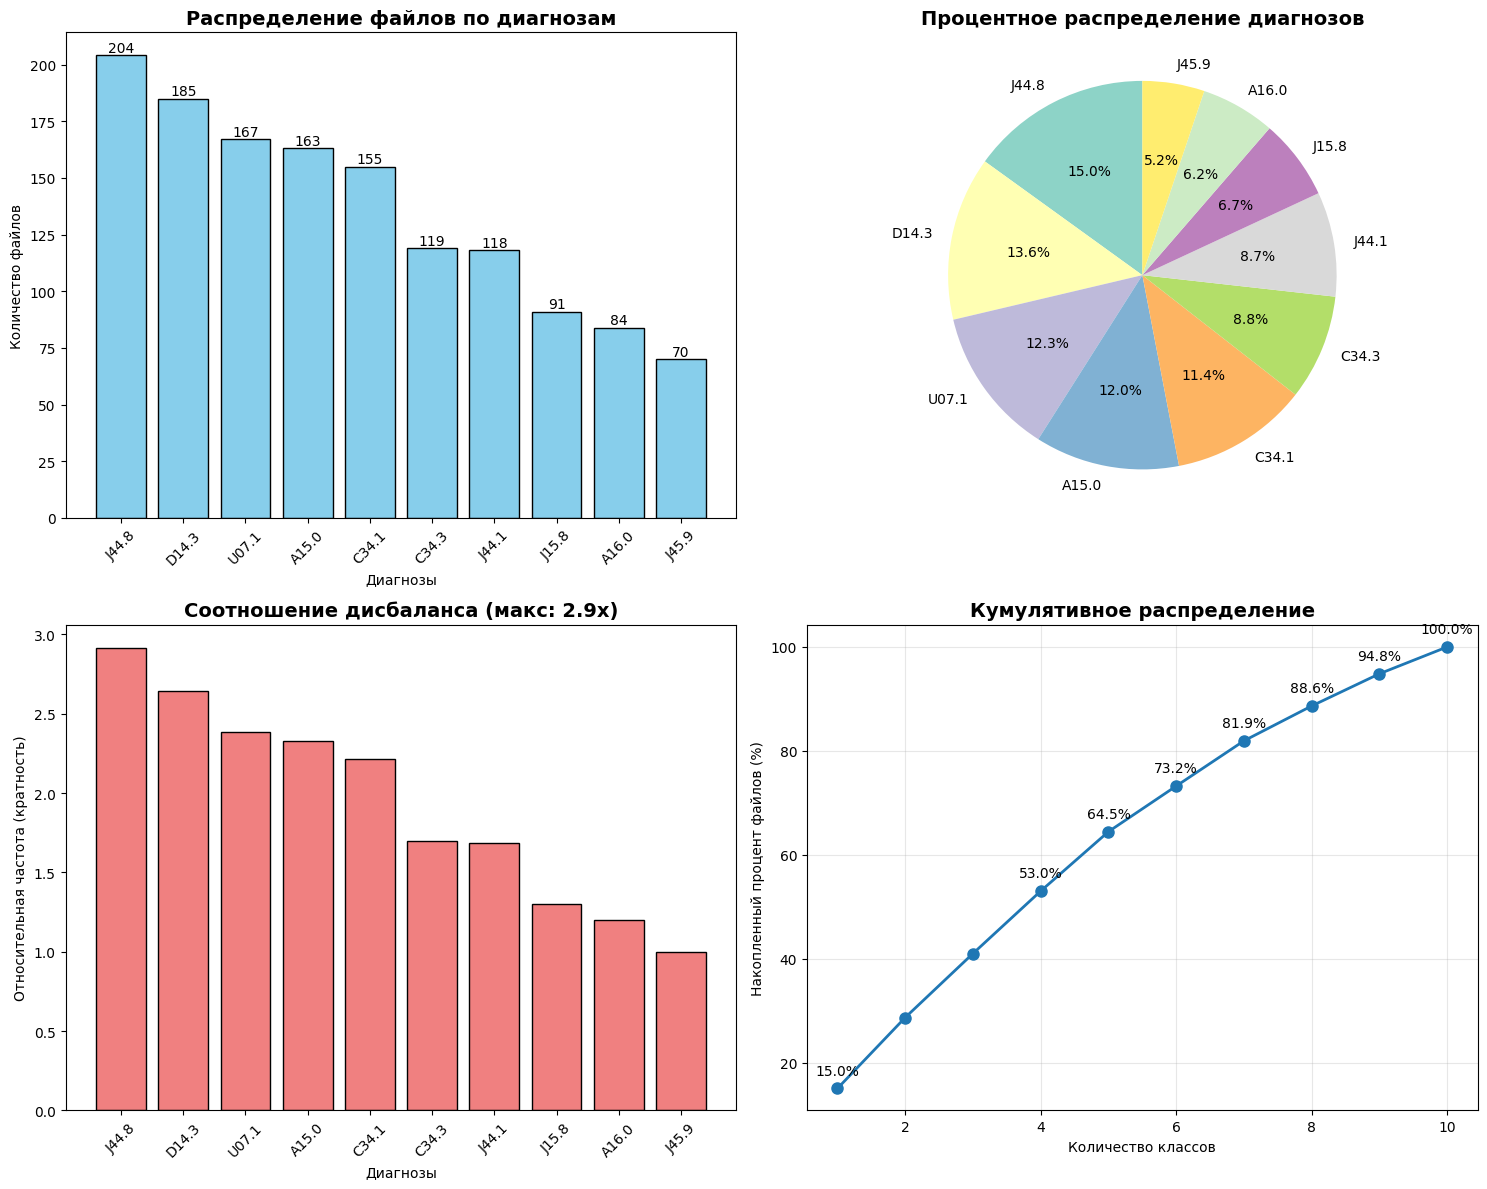


📊 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:
----------------------------------------
Топ-1 классов покрывают: 15.0% данных
Топ-2 классов покрывают: 28.7% данных
Топ-3 классов покрывают: 41.0% данных
Топ-4 классов покрывают: 53.0% данных

Анализ по квантилям:
25-й перцентиль: 97.8 файлов
50-й перцентиль (медиана): 137.0 файлов
75-й перцентиль: 166.0 файлов

Классификация классов:
Мажоритарные классы (>1.5x среднего): 1
Миноритарные классы (<0.5x среднего): 0


In [10]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import numpy as np

def analyze_class_imbalance(folder_path):
    """
    Комплексный анализ дисбаланса классов в папке с топ-7 диагнозами
    """
    if not os.path.exists(folder_path):
        print(f"Ошибка: Папка '{folder_path}' не существует!")
        return
    
    # Собираем данные о диагнозах
    diagnosis_counter = Counter()
    total_files = 0
    
    print("📊 АНАЛИЗ ДИСБАЛАНСА КЛАССОВ")
    print("=" * 60)
    
    # Читаем файлы и считаем диагнозы
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        total_files += 1
                        
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
    
    if total_files == 0:
        print("В папке не найдено файлов с диагнозами!")
        return
    
    # Сортируем по убыванию частоты
    diagnoses_sorted = diagnosis_counter.most_common()
    
    # БАЗОВАЯ СТАТИСТИКА
    print(f"\n📈 БАЗОВАЯ СТАТИСТИКА:")
    print("-" * 40)
    print(f"Всего файлов: {total_files}")
    print(f"Количество классов: {len(diagnosis_counter)}")
    print(f"Среднее количество на класс: {total_files/len(diagnosis_counter):.1f}")
    
    # РАСПРЕДЕЛЕНИЕ КЛАССОВ
    print(f"\n📋 РАСПРЕДЕЛЕНИЕ КЛАССОВ:")
    print("-" * 50)
    print(f"{'Диагноз':<10} {'Количество':<12} {'Процент':<10} {'Отн. частота':<15}")
    print("-" * 50)
    
    for diagnosis, count in diagnoses_sorted:
        percentage = (count / total_files) * 100
        relative_freq = count / min(diagnosis_counter.values())
        print(f"{diagnosis:<10} {count:<12} {percentage:<10.1f}% {relative_freq:<15.1f}x")
    
    # СТАТИСТИКА ДИСБАЛАНСА
    print(f"\n⚖️ СТАТИСТИКА ДИСБАЛАНСА:")
    print("-" * 40)
    
    counts = [count for _, count in diagnoses_sorted]
    max_count = max(counts)
    min_count = min(counts)
    mean_count = np.mean(counts)
    std_count = np.std(counts)
    
    imbalance_ratio = max_count / min_count
    cv = (std_count / mean_count) * 100  # Коэффициент вариации
    
    print(f"Самый частый класс: {max_count} файлов")
    print(f"Самый редкий класс: {min_count} файлов")
    print(f"Соотношение дисбаланса: {imbalance_ratio:.1f}:1")
    print(f"Коэффициент вариации: {cv:.1f}%")
    print(f"Стандартное отклонение: {std_count:.1f}")
    
    # УРОВЕНЬ ДИСБАЛАНСА
    print(f"\n🎯 УРОВЕНЬ ДИСБАЛАНСА:")
    print("-" * 40)
    
    if imbalance_ratio < 2:
        level = "СБАЛАНСИРОВАННЫЙ"
    elif imbalance_ratio < 5:
        level = "НЕБОЛЬШОЙ ДИСБАЛАНС"
    elif imbalance_ratio < 10:
        level = "ЗНАЧИТЕЛЬНЫЙ ДИСБАЛАНС"
    else:
        level = "СИЛЬНЫЙ ДИСБАЛАНС"
    
    print(f"{level} (соотношение: {imbalance_ratio:.1f}:1)")
    
    # РЕКОМЕНДАЦИИ
    print(f"\n💡 РЕКОМЕНДАЦИИ:")
    print("-" * 40)
    
    if imbalance_ratio > 10:
        print("• Используйте oversampling (SMOTE) для миноритарных классов")
        print("• Используйте undersampling для мажоритарных классов")
        print("• Применяйте взвешенные функции потерь")
        print("• Рассмотрите ансамблирование методов")
    elif imbalance_ratio > 5:
        print("• Рекомендуется SMOTE или ADASYN")
        print("• Используйте взвешенные классы в алгоритмах")
        print("• Попробуйте комбинацию oversampling/undersampling")
    elif imbalance_ratio > 2:
        print("• Можно использовать простой oversampling")
        print("• Взвешивание классов может помочь")
        print("• Мониторуйте метрики для миноритарных классов")
    else:
        print("• Дисбаланс незначительный, можно использовать стандартные методы")
    
    # ВИЗУАЛИЗАЦИЯ
    visualize_imbalance(diagnoses_sorted, total_files, imbalance_ratio)
    
    # ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
    additional_analysis(diagnoses_sorted, total_files)

def visualize_imbalance(diagnoses_sorted, total_files, imbalance_ratio):
    """
    Визуализация дисбаланса классов
    """
    diagnoses, counts = zip(*diagnoses_sorted)
    
    # Создаем графики
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # График 1: Столбчатая диаграмма
    bars = ax1.bar(range(len(diagnoses)), counts, color='skyblue', edgecolor='black')
    ax1.set_title('Распределение файлов по диагнозам', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Диагнозы')
    ax1.set_ylabel('Количество файлов')
    ax1.set_xticks(range(len(diagnoses)))
    ax1.set_xticklabels(diagnoses, rotation=45)
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{count}', ha='center', va='bottom', fontsize=10)
    
    # График 2: Круговая диаграмма
    colors = plt.cm.Set3(np.linspace(0, 1, len(diagnoses)))
    wedges, texts, autotexts = ax2.pie(counts, labels=diagnoses, autopct='%1.1f%%', 
                                      colors=colors, startangle=90)
    ax2.set_title('Процентное распределение диагнозов', fontsize=14, fontweight='bold')
    
    # График 3: Соотношение дисбаланса
    normalized_counts = [count / min(counts) for count in counts]
    ax3.bar(range(len(diagnoses)), normalized_counts, color='lightcoral', edgecolor='black')
    ax3.set_title(f'Соотношение дисбаланса (макс: {imbalance_ratio:.1f}x)', 
                 fontsize=14, fontweight='bold')
    ax3.set_xlabel('Диагнозы')
    ax3.set_ylabel('Относительная частота (кратность)')
    ax3.set_xticks(range(len(diagnoses)))
    ax3.set_xticklabels(diagnoses, rotation=45)
    
    # График 4: Кумулятивное распределение
    cumulative_percentage = np.cumsum(counts) / total_files * 100
    ax4.plot(range(1, len(diagnoses) + 1), cumulative_percentage, 
             marker='o', linewidth=2, markersize=8)
    ax4.set_title('Кумулятивное распределение', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Количество классов')
    ax4.set_ylabel('Накопленный процент файлов (%)')
    ax4.grid(True, alpha=0.3)
    
    # Добавляем ориентиры
    for i, (n, pct) in enumerate(zip(range(1, len(diagnoses) + 1), cumulative_percentage)):
        if pct >= 50 or i == 0 or i == len(diagnoses) - 1:
            ax4.annotate(f'{pct:.1f}%', (n, pct), textcoords="offset points", 
                        xytext=(0,10), ha='center')
    
    plt.tight_layout()
    plt.show()

def additional_analysis(diagnoses_sorted, total_files):
    """
    Дополнительный анализ дисбаланса
    """
    print(f"\n📊 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:")
    print("-" * 40)
    
    counts = [count for _, count in diagnoses_sorted]
    
    # Анализ покрытия
    top_n_coverage = []
    for n in [1, 2, 3, 4]:
        coverage = sum(counts[:n]) / total_files * 100
        top_n_coverage.append((n, coverage))
        print(f"Топ-{n} классов покрывают: {coverage:.1f}% данных")
    
    # Анализ по квантилям
    print(f"\nАнализ по квантилям:")
    q25 = np.percentile(counts, 25)
    q50 = np.percentile(counts, 50)
    q75 = np.percentile(counts, 75)
    
    print(f"25-й перцентиль: {q25:.1f} файлов")
    print(f"50-й перцентиль (медиана): {q50:.1f} файлов")
    print(f"75-й перцентиль: {q75:.1f} файлов")
    
    # Классификация классов
    mean_count = np.mean(counts)
    major_classes = [d for d, c in diagnoses_sorted if c > mean_count * 1.5]
    minor_classes = [d for d, c in diagnoses_sorted if c < mean_count * 0.5]
    
    print(f"\nКлассификация классов:")
    print(f"Мажоритарные классы (>1.5x среднего): {len(major_classes)}")
    print(f"Миноритарные классы (<0.5x среднего): {len(minor_classes)}")
    
    if minor_classes:
        print(f"Миноритарные классы: {', '.join(minor_classes)}")

# Анализ для исходных данных (сравнение)
def compare_with_original(source_folder, top7_folder):
    """
    Сравнивает дисбаланс в исходных данных и в топ-7
    """
    def count_diagnoses(folder):
        counter = Counter()
        for filename in os.listdir(folder):
            if filename.endswith('.json'):
                file_path = os.path.join(folder, filename)
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        data = json.load(file)
                    if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                        diagnosis = data['diagnosis']['diagnosis_text']
                        if diagnosis:
                            counter[diagnosis] += 1
                except:
                    continue
        return counter
    
    print("\n" + "="*60)
    print("СРАВНЕНИЕ С ИСХОДНЫМИ ДАННЫМИ")
    print("="*60)
    
    original_counts = count_diagnoses(source_folder)
    top7_counts = count_diagnoses(top7_folder)
    
    original_imbalance = max(original_counts.values()) / min(original_counts.values())
    top7_imbalance = max(top7_counts.values()) / min(top7_counts.values())
    
    print(f"Исходные данные:")
    print(f"  - Классов: {len(original_counts)}")
    print(f"  - Дисбаланс: {original_imbalance:.1f}:1")
    
    print(f"\nТоп-7 данные:")
    print(f"  - Классов: {len(top7_counts)}")
    print(f"  - Дисбаланс: {top7_imbalance:.1f}:1")
    
    improvement = (original_imbalance - top7_imbalance) / original_imbalance * 100
    print(f"\nУлучшение баланса: {improvement:.1f}%")

# Запуск анализа
if __name__ == "__main__":
    folder_path = "top10_diagnoses_files"
    
    # Основной анализ дисбаланса
    analyze_class_imbalance(folder_path)
    
    # Сравнение с исходными данными (раскомментируйте если нужно)
    # compare_with_original("preprocessed_medical_results", folder_path)

По результатом анализа видно, что дисбаланс не критичный, можно работать с этим

# Перевод текста в числа (единый формат)

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import json
import os
import shutil
import re
from datetime import datetime

class MedicalFeatureExtractor:
    """Извлечение признаков из медицинских JSON файлов"""
    
    def __init__(self):
        self.symptom_patterns = self._load_symptom_patterns()
        self.medical_terms = self._load_medical_terms()
        self.scaler = StandardScaler()
        
    def _load_symptom_patterns(self):
        """Паттерны для поиска симптомов"""
        return {
            'кашель': {
                'keywords': ['кашель', 'кашля', 'кашле', 'откашливан'],
                'intensity': {
                    'легкий': ['покашливан', 'легкий кашель', 'незначительный кашель'],
                    'средний': ['кашель', 'малопродуктивный', 'постоянный кашель'],
                    'сильный': ['сильный кашель', 'надсадный', 'мучительный', 'приступ кашля']
                }
            },
            'температура': {
                'keywords': ['температур', 'лихорадк', 'жар', 'озноб', 'гипертерми', 'субфебрильн', 'фебрильн'],
                'intensity': {
                    'легкая': ['субфебрильн', '37.', '37,'],
                    'средняя': ['температур', '38.', '38,', 'фебрильн'],
                    'высокая': ['высокая температур', '39.', '39,', '40.', '40,', 'гипертерми']
                }
            },
            'одышка': {
                'keywords': ['одышк', 'затруднен', 'дыхан', 'нехватк', 'воздух', 'удушь', 'диспноэ'],
                'intensity': {
                    'легкая': ['одышка при нагрузк', 'незначительная одышка'],
                    'средняя': ['одышк', 'затруднен', 'дыхан'],
                    'тяжелая': ['одышка в покое', 'сильная одышка', 'удушь']
                }
            },
            'слабость': {
                'keywords': ['слабост', 'усталост', 'недомогание', 'разбитост', 'астени', 'утомляемост'],
                'intensity': {
                    'легкая': ['слабост', 'недомогание'],
                    'средняя': ['выраженная слабост', 'сильная слабост'],
                    'тяжелая': ['резкая слабост', 'обездвиженност']
                }
            },
            'головная_боль': {
                'keywords': ['головная боль', 'головные боли', 'головной боль', 'цефалги', 'мигрен', 'болит голова'],
                'intensity': {
                    'легкая': ['головная боль', 'незначительная головная боль'],
                    'средняя': ['сильная головная боль', 'выраженная головная боль'],
                    'тяжелая': ['нестерпимая головная боль', 'мучительная головная боль']
                }
            },
            'рвота': {
                'keywords': ['рвот', 'тошнот', 'тошнит'],
                'intensity': {
                    'легкая': ['тошнот', 'подташниван'],
                    'средняя': ['рвот', 'однократн'],
                    'тяжелая': ['многократн', 'неукротим']
                }
            },
            'насморк': {
                'keywords': ['насморк', 'заложенност', 'нос', 'ринит', 'выделен', 'носа'],
                'intensity': {
                    'легкая': ['насморк', 'заложенност носа'],
                    'средняя': ['сильный насморк', 'обильные выделен'],
                    'тяжелая': ['постоянный насморк', 'непроходимост']
                }
            },
            'боль_в_груди': {
                'keywords': ['боль в груд', 'боли в груд', 'кардиалги', 'болит груд', 'боль за грудин'],
                'intensity': {
                    'легкая': ['незначительная боль', 'дискомфорт в груд'],
                    'средняя': ['боль в груд', 'боли в груд'],
                    'тяжелая': ['сильная боль', 'острая боль', 'нестерпимая боль']
                }
            }
        }
    
    def _load_medical_terms(self):
        """Медицинские термины для поиска"""
        return {
            'аускультация': ['аускультац', 'хрип', 'дыхан', 'жесткое дыхан', 'ослаблен'],
            'перкуссия': ['перкусс', 'перкуторн'],
            'пальпация': ['пальпац', 'пальпирует'],
            'отеки': ['отек', 'пастозност', 'отечност'],
            'цианоз': ['цианоз', 'синюшност', 'акроцианоз'],
            'тахикардия': ['тахикарди', 'учащен', 'сердцебиен', 'чсс'],
            'сатурация': ['сатурац', 'spo2', 'насыщен', 'кислород'],
            'артериальное_давление': ['артериальн', 'давлен', 'ад'],
            'анализ_крови': ['анализ кров', 'лейкоцит', 'гемоглобин', 'соэ', 'с-реактивн']
        }
    
    def find_symptom_intensity(self, text, symptom_name):
        """Находит интенсивность симптома в тексте"""
        if not text or not isinstance(text, str):
            return 0
            
        text_lower = text.lower()
        symptom_data = self.symptom_patterns.get(symptom_name)
        
        if not symptom_data:
            return 0
        
        # Проверяем наличие ключевых слов
        found_keywords = [kw for kw in symptom_data['keywords'] if kw in text_lower]
        if not found_keywords:
            return 0
        
        # Определяем интенсивность
        intensity = 1  # минимальная интенсивность
        
        # Безопасно проверяем интенсивности
        intensity_levels = symptom_data.get('intensity', {})
        
        # Проверяем тяжелую интенсивность (с защитой от отсутствия ключа)
        if 'тяжелая' in intensity_levels:
            for pattern in intensity_levels['тяжелая']:
                if pattern in text_lower:
                    return 3
        
        # Проверяем среднюю интенсивность (с защитой от отсутствия ключа)
        if 'средняя' in intensity_levels:
            for pattern in intensity_levels['средняя']:
                if pattern in text_lower:
                    intensity = max(intensity, 2)
        
        return intensity
    
    def find_medical_term(self, text, term_name):
        """Проверяет наличие медицинского термина"""
        if not text or not isinstance(text, str):
            return 0
            
        text_lower = text.lower()
        keywords = self.medical_terms.get(term_name, [])
        
        return 1 if any(kw in text_lower for kw in keywords) else 0
    
    def safe_get_text(self, data, *keys):
        """Безопасно извлекает текст из вложенной структуры"""
        current = data
        for key in keys:
            if isinstance(current, dict):
                current = current.get(key)
            else:
                return ''
        return str(current) if current is not None else ''
    
    def extract_text_data(self, data):
        """Извлекает текстовые данные из JSON структуры"""
        texts = []
        
        # Жалобы
        complaints_text = self.safe_get_text(data, 'complaints', 'text')
        complaints_processed = self.safe_get_text(data, 'complaints', 'processed_text')
        
        if complaints_text:
            texts.append(complaints_text)
        if complaints_processed:
            texts.append(complaints_processed)
        
        # Анамнез заболевания
        history_text = self.safe_get_text(data, 'disease_history', 'text')
        history_processed = self.safe_get_text(data, 'disease_history', 'processed_text')
        
        if history_text:
            texts.append(history_text)
        if history_processed:
            texts.append(history_processed)
        
        # Физикальное обследование
        examination_value = self.safe_get_text(data, 'physical_examination', 'value')
        examination_processed = self.safe_get_text(data, 'physical_examination', 'processed_text')
        
        if examination_value:
            texts.append(examination_value)
        if examination_processed:
            texts.append(examination_processed)
        
        return ' '.join(texts)
    
    def safe_extract_numeric(self, value_data):
        """Безопасно извлекает числовое значение"""
        if value_data is None:
            return 0
        
        value = 0
        if isinstance(value_data, dict):
            value = value_data.get('value', 0)
        elif isinstance(value_data, (int, float)):
            value = value_data
        elif isinstance(value_data, str):
            numbers = re.findall(r'\d+\.?\d*', value_data.replace(',', '.'))
            value = float(numbers[0]) if numbers else 0
        
        try:
            return float(value)
        except (ValueError, TypeError):
            return 0
    
    def extract_numeric_features(self, data):
        """Извлекает числовые параметры"""
        features = {}
        
        numeric_params = data.get('numeric_parameters', {})
        if not isinstance(numeric_params, dict):
            return features
        
        # Витальные признаки
        vital_signs = {
            'Температура тела': 'temp_body',
            'Артериальное давление систолическое': 'bp_systolic',
            'Артериальное давление диастолическое': 'bp_diastolic',
            'Частота сердечных сокращений': 'heart_rate',
            'Пульс': 'pulse',
            'Сатурация': 'saturation',
            'Частота дыхания': 'resp_rate'
        }
        
        for ru_name, en_name in vital_signs.items():
            value_data = numeric_params.get(ru_name)
            value = self.safe_extract_numeric(value_data)
            features[f'vital_{en_name}'] = value
        
        # Лабораторные показатели
        lab_tests = {
            'Лейкоциты, количество в крови методом автоматизированного подсчёта': 'wbc',
            'С-реактивный белок, массовая концентрация в сыворотке или плазме крови': 'crp',
            'Глюкоза, молярная концентрация в сыворотке или плазме крови': 'glucose',
            'Белок общий, массовая концентрация в сыворотке или плазме крови': 'total_protein'
        }
        
        for ru_name, en_name in lab_tests.items():
            value_data = numeric_params.get(ru_name)
            value = self.safe_extract_numeric(value_data)
            features[f'lab_{en_name}'] = value
        
        return features
    
    def extract_features_from_json(self, data):
        """Извлекает все признаки из JSON данных"""
        features = {}
        
        try:
            # 1. Числовые параметры
            numeric_features = self.extract_numeric_features(data)
            features.update(numeric_features)
            
            # 2. Текстовые данные
            all_text = self.extract_text_data(data)
            
            # 3. Симптомы
            for symptom_name in self.symptom_patterns.keys():
                intensity = self.find_symptom_intensity(all_text, symptom_name)
                features[f'has_{symptom_name}'] = 1 if intensity > 0 else 0
                features[f'intensity_{symptom_name}'] = intensity
            
            # 4. Медицинские термины
            for term_name in self.medical_terms.keys():
                has_term = self.find_medical_term(all_text, term_name)
                features[f'has_{term_name}'] = has_term
            
            # 5. Статистика по текстам
            complaints_text = self.safe_get_text(data, 'complaints', 'text') or self.safe_get_text(data, 'complaints', 'processed_text')
            history_text = self.safe_get_text(data, 'disease_history', 'text') or self.safe_get_text(data, 'disease_history', 'processed_text')
            examination_text = self.safe_get_text(data, 'physical_examination', 'value') or self.safe_get_text(data, 'physical_examination', 'processed_text')
            
            features['text_length_complaints'] = len(str(complaints_text))
            features['text_length_history'] = len(str(history_text))
            features['text_length_examination'] = len(str(examination_text))
            
            # 6. Сводные показатели
            symptom_names = list(self.symptom_patterns.keys())
            total_symptoms = sum(features.get(f'has_{symptom}', 0) for symptom in symptom_names)
            total_intensity = sum(features.get(f'intensity_{symptom}', 0) for symptom in symptom_names)
            
            features['total_symptoms_count'] = total_symptoms
            features['total_symptoms_intensity'] = total_intensity
            features['symptoms_diversity'] = total_symptoms / len(symptom_names) if symptom_names else 0
            
        except Exception as e:
            print(f"Ошибка при извлечении признаков: {e}")
            # Возвращаем пустые признаки при ошибке
        
        return features

def process_json_files(source_folder, target_folder):
    """Обрабатывает все JSON файлы в папке"""
    
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)
        print(f"Создана папка: {target_folder}")
    
    extractor = MedicalFeatureExtractor()
    processed_files = 0
    error_files = []
    
    all_features = []
    filenames = []
    
    for filename in os.listdir(source_folder):
        if filename.endswith('.json'):
            source_path = os.path.join(source_folder, filename)
            target_path = os.path.join(target_folder, filename)
            
            try:
                with open(source_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                
                # Извлекаем признаки
                features = extractor.extract_features_from_json(data)
                
                # Добавляем имя файла и диагноз
                features['filename'] = filename
                
                diagnosis_data = data.get('diagnosis', {})
                if isinstance(diagnosis_data, dict):
                    features['diagnosis_code'] = diagnosis_data.get('diagnosis_text', 'Unknown')
                    features['diagnosis_name'] = diagnosis_data.get('display_name', 'Unknown')
                else:
                    features['diagnosis_code'] = 'Unknown'
                    features['diagnosis_name'] = 'Unknown'
                
                # Сохраняем обогащенный файл
                data['extracted_features'] = features
                data['feature_extraction_date'] = datetime.now().isoformat()
                
                with open(target_path, 'w', encoding='utf-8') as f:
                    json.dump(data, f, ensure_ascii=False, indent=2)
                
                all_features.append(features)
                filenames.append(filename)
                processed_files += 1
                
                if processed_files % 100 == 0:
                    print(f"Обработано файлов: {processed_files}")
                    
            except Exception as e:
                print(f"Ошибка при обработке файла {filename}: {e}")
                error_files.append(filename)
                # Копируем оригинальный файл при ошибке
                try:
                    shutil.copy2(source_path, target_path)
                except:
                    pass
    
    print(f"\nОбработка завершена:")
    print(f"Успешно обработано: {processed_files} файлов")
    print(f"С ошибками: {len(error_files)} файлов")
    
    return all_features, filenames, error_files

def analyze_features(features_list):
    """Анализирует извлеченные признаки"""
    if not features_list:
        print("Нет данных для анализа!")
        return None
    
    df = pd.DataFrame(features_list)
    
    print(f"\n📊 АНАЛИЗ ДАННЫХ:")
    print("=" * 60)
    print(f"Всего записей: {len(df)}")
    print(f"Всего признаков: {df.shape[1]}")
    
    # Анализ симптомов
    print(f"\n🔍 СТАТИСТИКА СИМПТОМОВ:")
    print("-" * 50)
    
    symptom_columns = [col for col in df.columns if col.startswith('has_') and any(symptom in col for symptom in ['кашель', 'температура', 'одышка', 'слабость', 'головная_боль', 'рвота', 'насморк', 'боль_в_груди'])]
    
    for symptom_col in symptom_columns:
        symptom_name = symptom_col.replace('has_', '')
        count = df[symptom_col].sum()
        percentage = (count / len(df)) * 100
        
        intensity_col = f'intensity_{symptom_name}'
        if intensity_col in df.columns:
            active_cases = df[df[symptom_col] == 1]
            if len(active_cases) > 0:
                avg_intensity = active_cases[intensity_col].mean()
                intensity_dist = active_cases[intensity_col].value_counts().sort_index()
                intensity_str = ', '.join([f"{level}:{count}" for level, count in intensity_dist.items()])
                print(f"{symptom_name:<15}: {count:4d} случаев ({percentage:5.1f}%), средняя интенсивность: {avg_intensity:.1f} [{intensity_str}]")
            else:
                print(f"{symptom_name:<15}: {count:4d} случаев ({percentage:5.1f}%)")
        else:
            print(f"{symptom_name:<15}: {count:4d} случаев ({percentage:5.1f}%)")
    
    # Топ-10 самых частых признаков
    print(f"\n🏆 ТОП-10 САМЫХ ЧАСТЫХ ПРИЗНАКОВ:")
    print("-" * 50)
    
    binary_features = [col for col in df.columns if col.startswith('has_')]
    if binary_features:
        feature_frequency = df[binary_features].sum().sort_values(ascending=False)
        
        for feature, count in feature_frequency.head(10).items():
            percentage = (count / len(df)) * 100
            print(f"{feature:<30}: {count:4d} случаев ({percentage:5.1f}%)")
    
    # Статистика по диагнозам
    if 'diagnosis_code' in df.columns:
        print(f"\n📋 РАСПРЕДЕЛЕНИЕ ДИАГНОЗОВ:")
        print("-" * 50)
        
        diagnosis_stats = df['diagnosis_code'].value_counts()
        for diagnosis, count in diagnosis_stats.head(10).items():
            percentage = (count / len(df)) * 100
            diagnosis_row = df[df['diagnosis_code'] == diagnosis].iloc[0] if not df[df['diagnosis_code'] == diagnosis].empty else None
            diagnosis_name = diagnosis_row.get('diagnosis_name', 'Unknown') if diagnosis_row is not None else 'Unknown'
            
            if diagnosis_name is None:
                diagnosis_name = 'Unknown'
            else:
                diagnosis_name = str(diagnosis_name)
            
            diagnosis_display = diagnosis_name[:40] if len(diagnosis_name) > 40 else diagnosis_name
            print(f"{diagnosis:<10}: {diagnosis_display:<40} - {count:4d} случаев ({percentage:5.1f}%)")
    
    return df

def debug_single_file(file_path):
    """Отладочная функция для одного проблемного файла"""
    print(f"\n🔍 ОТЛАДКА ФАЙЛА: {file_path}")
    print("=" * 70)
    
    extractor = MedicalFeatureExtractor()
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        print("Структура JSON файла:")
        print(json.dumps(data, ensure_ascii=False, indent=2)[:1000] + "...")
        
        # Проверяем наличие ключевых разделов
        print(f"\nКлючевые разделы:")
        for section in ['complaints', 'disease_history', 'physical_examination', 'diagnosis', 'numeric_parameters']:
            exists = section in data
            print(f"  {section}: {'✅' if exists else '❌'}")
            if exists and isinstance(data[section], dict):
                print(f"    Подразделы: {list(data[section].keys())}")
        
        # Извлекаем текст
        all_text = extractor.extract_text_data(data)
        print(f"\nИзвлеченный текст (первые 500 символов):")
        print(all_text[:500] + "..." if len(all_text) > 500 else all_text)
        
        # Проверяем симптомы
        print(f"\nОбнаруженные симптомы:")
        for symptom in ['кашель', 'температура', 'одышка', 'слабость']:
            intensity = extractor.find_symptom_intensity(all_text, symptom)
            if intensity > 0:
                print(f"✅ {symptom}: интенсивность {intensity}")
            else:
                symptom_data = extractor.symptom_patterns[symptom]
                found_kw = [kw for kw in symptom_data['keywords'] if kw in all_text.lower()]
                print(f"❌ {symptom}: ключевые слова {found_kw if found_kw else 'не найдены'}")
                
    except Exception as e:
        print(f"Ошибка при анализе файла: {e}")
        import traceback
        traceback.print_exc()

def main():
    source_folder = r"top10_diagnoses_files"
    enriched_folder = "enriched_medical_results_corrected"
    
    # Сначала проверяем проблемный файл
    problem_file = os.path.join(source_folder, "processed_Эпикриз_1505_v1.json")
    if os.path.exists(problem_file):
        debug_single_file(problem_file)
    
    # Обрабатываем файлы
    print(f"\n🎯 Обработка JSON файлов...")
    features_list, filenames, error_files = process_json_files(source_folder, enriched_folder)
    
    # Анализируем результаты
    df = analyze_features(features_list)
    
    if df is not None:
        # Сохраняем CSV
        output_path = "medical_features_analysis.csv"
        df.to_csv(output_path, index=False, encoding='utf-8')
        print(f"\n💾 Данные сохранены в: {output_path}")
        
        # Показываем пример извлеченных признаков
        print(f"\n🔬 ПРИМЕР ИЗВЛЕЧЕННЫХ ПРИЗНАКОВ:")
        print("-" * 50)
        if len(df) > 0:
            sample_features = df.iloc[0]
            
            # Активные симптомы
            active_symptoms = []
            symptom_cols = [col for col in df.columns if col.startswith('has_') and any(s in col for s in ['кашель', 'температура', 'одышка', 'слабость', 'головная_боль', 'рвота', 'насморк', 'боль_в_груди'])]
            
            for col in symptom_cols:
                if sample_features[col] == 1:
                    symptom_name = col.replace('has_', '')
                    active_symptoms.append(symptom_name)
            
            print(f"Активные симптомы: {', '.join(active_symptoms) if active_symptoms else 'нет'}")
            
            # Интенсивности
            if active_symptoms:
                print("Интенсивности:")
                for symptom in active_symptoms:
                    intensity = sample_features.get(f'intensity_{symptom}', 0)
                    levels = {1: 'легкая', 2: 'средняя', 3: 'тяжелая'}
                    level = levels.get(intensity, 'отсутствует')
                    print(f"  {symptom}: {intensity} ({level})")

if __name__ == "__main__":
    main()


🔍 ОТЛАДКА ФАЙЛА: top10_diagnoses_files\processed_Эпикриз_1505_v1.json
Структура JSON файла:
{
  "diagnosis": {
    "title": "ДИАГНОЗЫ ПАЦИЕНТА",
    "display_name": "Другие бактериальные пневмонии",
    "diagnosis_text": "J15.8"
  },
  "complaints": {
    "title": "ЖАЛОБЫ ПРИ ПОСТУПЛЕНИИ",
    "text": "Состояние: Средней тяжести.                  Жалобы: На кашель со слизисто-гнойной мокротой, одышку смешанного характера при незначительной нагрузке, лихорадку, слабость, потливость.",
    "processed_text": "средний тяжести. кашель со слизисто-гнойный мокротой, одышка смешанный характер незначительный нагрузке, лихорадку, слабость, потливость.",
    "medical_entities": {
      "symptoms": [
        "одышку",
        "кашель",
        "слабость",
        "потливость"
      ],
      "diagnoses": [],
      "measurements": []
    },
    "original_text_length": 182,
    "processed_text_length": 137
  },
  "social_history": {
    "title": "СОЦИАЛЬНЫЙ АНАМНЕЗ",
    "items": null
  },
  "diseas